### Introduction

Regression is a supervised learning technique where the goal is to predict a continuous numerical value based on one or more independent features. It finds relationships between variables so that predictions can be made.  

### Business Interest

Ecommerce company based in New York City that sells clothing online and also has an in-store style and clothing advice sessions.
The company is trying to decide whether to focus their efforts on their mobile app experience or their website.

Based on the available data from customer purchases, I have used regression to identify which platform is driving better revenue and decide how the company should strategize their investment between their mobile app and website.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os

#pip3 install pandas

### Data Collection

In [18]:
customer_data=pd.read_csv('./Ecommerce Customers')

Understanding the data

The customer data includes : 'Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership' and 'Yearly Amount Spent'.

Here we know that the two crucial attribute are 'Time on App'and 'Time on Website', as we want to know which one has more influence on the 'Yearly Amount Spent'.

We need to examine the relationship between all attributes to ensure that we make smart data driven decisions.

In [14]:
customer_data.head()
#customer_data.columns

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092



### Identifying the target variable

In this scenerio since 'Yearly Amount Spent' is the indicator of sucessful business, it can be considered as the target variable.
'Yearly Amount Spent' is potentially influenced by the other attributes like 'Avg. Session Length', 'Time on App','Time on Website' and 'Length of Membership'.

### Data Cleaning and Feature Engineering

The customer_data does not have null values or outliers and thus does not require any additional data cleaning.
All the data seem to be in a compareable format and hence does not have to be scaled or normalized.
The data does not have categorical values either and hence does not require One-Hot Encoding.

In [15]:
#to check for null values

customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [19]:
customer_data.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


### Dimentionality reduction 

The attributes 'Email', 'Address' and 'Avatar' does not influence customer's online shopping behavior and thus they will be ignored in the following steps.


### Exploratory Data Analysis

All these 8 attributes seems neccesary for the analysis, but to confirm that we need to perform some exploratory analysis to check the relationship between these attributes.

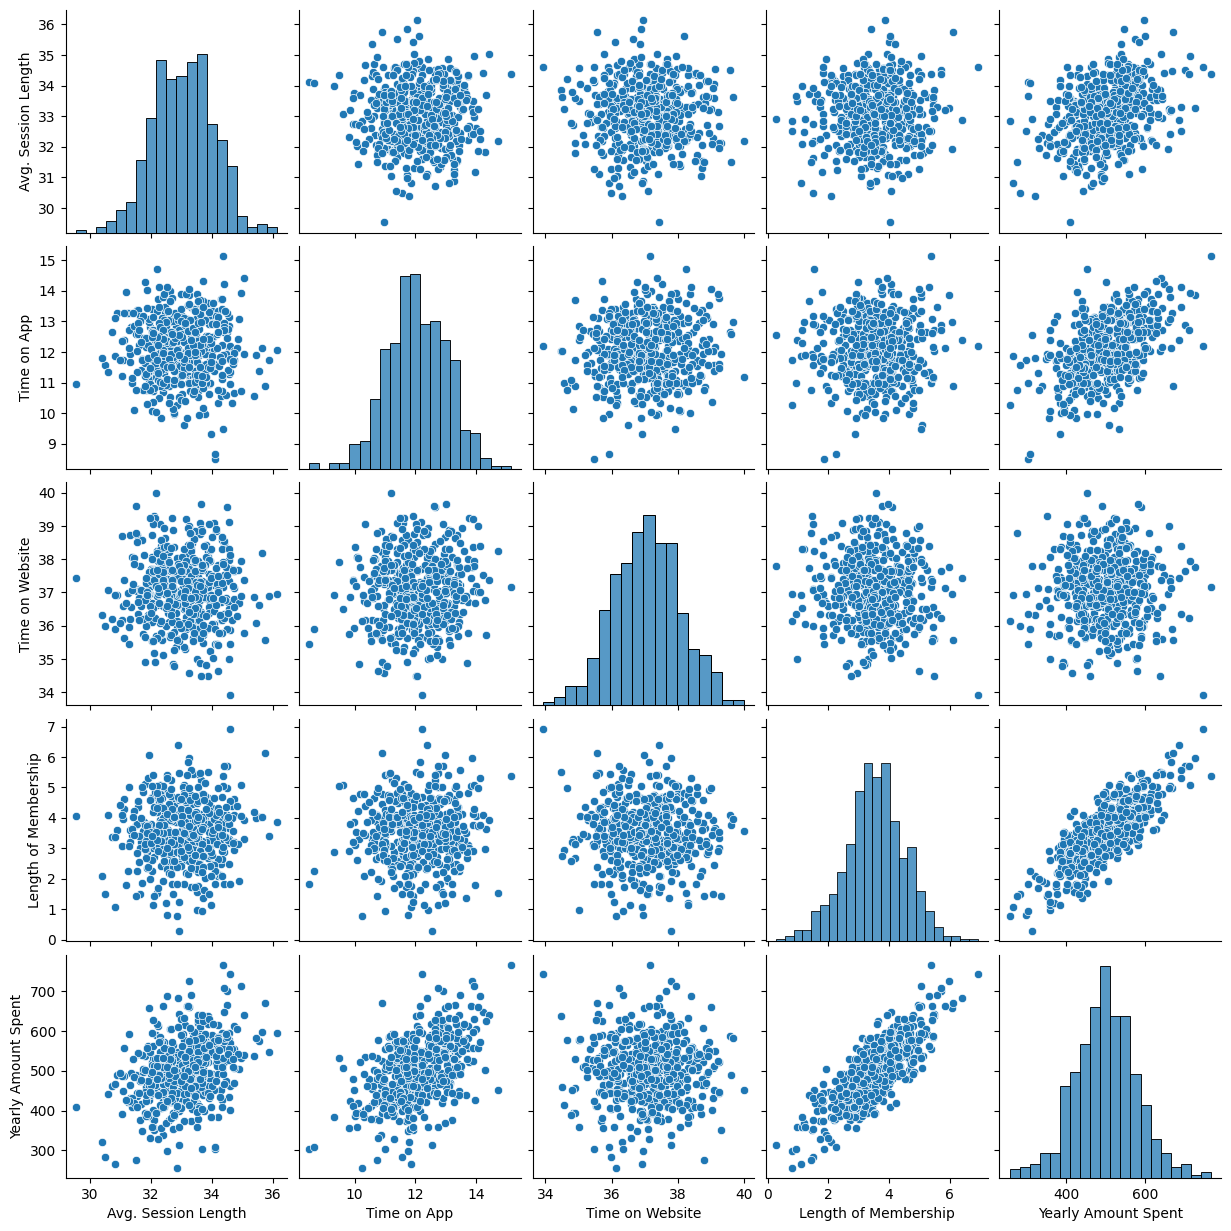

In [ ]:
# using pairplot to plot each attribute against the other 
# checking if any attributes have linear relationship

sns.pairplot(customer_data)

# pairplot is a matrix of graphs that enables the visualization of the relationship between each pair of attributes in a dataset

'Yearly Amount Spent' and 'Length of Membership' have an evident linear relationship

'Yearly Amount Spent' and 'Time on App' also seem to have a slightly linear relationship

Let's visualize these relationship using lmplot (a combination of Scatter Plot and Regression Line)

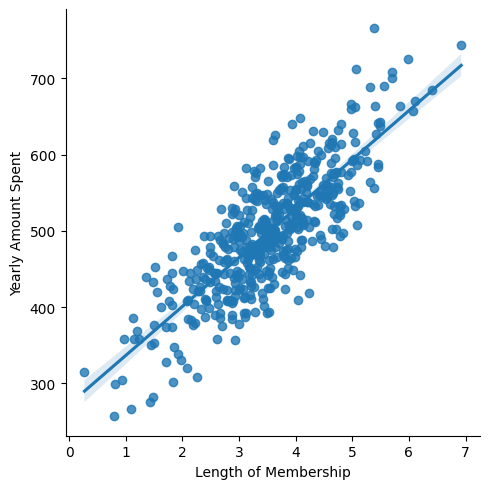

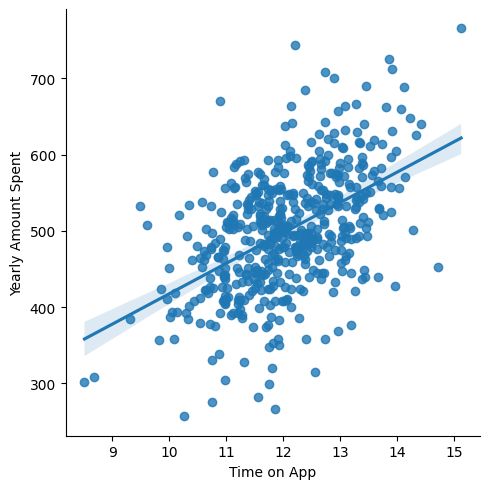

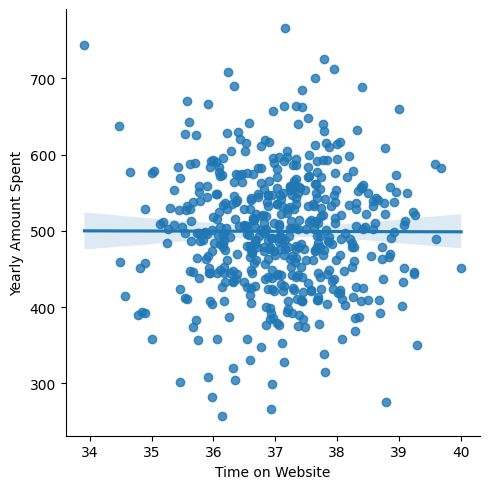

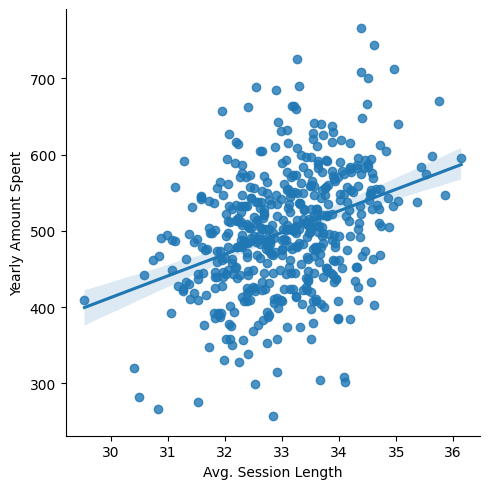

In [40]:
sns.lmplot(x='Length of Membership', y='Yearly Amount Spent',data=customer_data)
sns.lmplot(x='Time on App', y='Yearly Amount Spent',data=customer_data)
sns.lmplot(x='Time on Website', y='Yearly Amount Spent',data=customer_data)
sns.lmplot(x='Avg. Session Length', y='Yearly Amount Spent',data=customer_data)

### Training model

In [24]:
from sklearn.model_selection import train_test_split

X = customer_data[['Avg. Session Length', 'Time on App','Time on Website', 'Length of Membership']]

y= customer_data['Yearly Amount Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=97)

Text(0, 0.5, 'Predicted values for "Yearly Amount Spent" ')

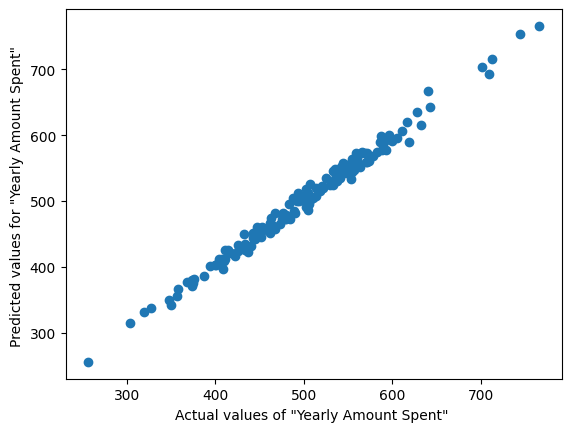

In [33]:
from sklearn.linear_model import LinearRegression

lm=LinearRegression()

lm.fit(X_train,y_train)

predictions=lm.predict(X_test)

plt.scatter(y_test,predictions)
plt.xlabel('Actual values of "Yearly Amount Spent" ') #from test dataset
plt.ylabel('Predicted values for "Yearly Amount Spent" ') #made by the linear regression model

The closer the points are to the line y = x, the better the model is at predicting the actual values.

The points align closely along a diagonal line indicating a strong correlation.

### Model Evaluation

In [38]:
from sklearn import metrics

mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = mse ** 0.5  # Root Mean Squared Error
r2 = metrics.r2_score(y_test, predictions)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print("R-squared Score:", r2)

MAE: 7.22814865343083
MSE: 79.81305165097447
RMSE: 8.933815066978635
R-squared Score: 0.9890046246741234


In [34]:
feature_names = X.columns
coefficients = lm.coef_

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")

Avg. Session Length: 25.981549723495778
Time on App: 38.590158753114125
Time on Website: 0.19040527751101205
Length of Membership: 61.279096544821854


coefficients of the respective input features,represents the magnitude and direction of the relationship between that feature and the predicted value of y.

A higher coefficient means the feature has a larger effect on the target variable



### Conclusion and findings

By looking at the coefficients, we notice that time on app has a higher coefficient that time on website.

Thus based on this analysis, since time on app has a linear and stronger influence relationship with 'Yearly Amount Spent', I would suggest the company to invest more on their app platorm campared to the website.